In [9]:
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.datasource import YahooDataSource
from src.prediction import PredictionModeling
from src.bayesianopt import bayesianOpt
from src.riskmeasure import CumulativeReturn, ExponationalUtility
from src.utils import buy_signal_plots, calculate_drawdown
from src.utils import find_cointegrated_pairs,get_top_k_pairs,get_cointergrated_coeff
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Data Extraction

In [10]:
# Extract the Data from the Yahoo Data Source
start_date = datetime.datetime(2019, 3, 29)
end_date = datetime.datetime(2024, 3, 29)
tickers  =  ['SPY','AAPL','ADBE','EBAY','MSFT','QCOM',
                 'HPQ','JNPR','AMD','IBM','DAL','KO']
columns =   ["High","Close","Low","Volume"]
ds = YahooDataSource(start_date,end_date,tickers,columns)

In [11]:
# Get only Close column data
df_pair_search = ds.get_data_by_column_tickers(columns=["Close"],tickers=-1)

In [12]:
df_pair_search.head(n=5)
scores, pvalues, pairs = find_cointegrated_pairs(df_pair_search)

top_pairs = get_top_k_pairs(pairs,5)
print("Top pairs",top_pairs)

# Get first pair
tickers = ds.get_tickers(top_pairs[0][0])
print("Top ticker",tickers)

Top pairs [(('AMD_Close', 'MSFT_Close'), 0.018010415898206872)]
Top ticker ['AMD', 'MSFT']


In [13]:
first_series = 'MSFT_Close'
second_series =  'AMD_Close'

In [14]:
# Gather High, Low ,Close , Volume of selected stocks
columns = ["High","Close","Low","Volume"]
df_raw = ds.get_data_by_column_tickers(columns=columns,tickers=tickers)

In [15]:
df_raw

,AMD_Close,AMD_Volume,AMD_Low,AMD_High,MSFT_Close,MSFT_Volume,MSFT_Low,MSFT_High
0,25.520000,53502800,25.250000,25.730000,111.415558,25399800,110.489768,111.774534
1,26.360001,63000300,25.830000,26.559999,112.435814,22789100,111.566710,112.520839
2,26.750000,53358800,26.090000,26.799999,112.596413,18142300,111.963472,112.870371
3,29.020000,197650500,27.879999,29.950001,113.333244,22860700,112.558607,113.767796
4,29.090000,82191100,28.610001,29.389999,112.757004,20112800,111.831214,113.578878
...,...,...,...,...,...,...,...,...
1254,179.649994,57832100,175.050003,180.759995,425.491516,17636500,422.841763,426.603025
1255,178.630005,71935300,172.000000,182.800003,419.656067,18060500,418.415538,424.171611
1256,177.869995,65322400,176.330002,182.600006,418.455231,16725600,418.157516,422.762344
1257,179.589996,55685600,175.399994,181.229996,418.236908,16705000,415.835261,421.234045


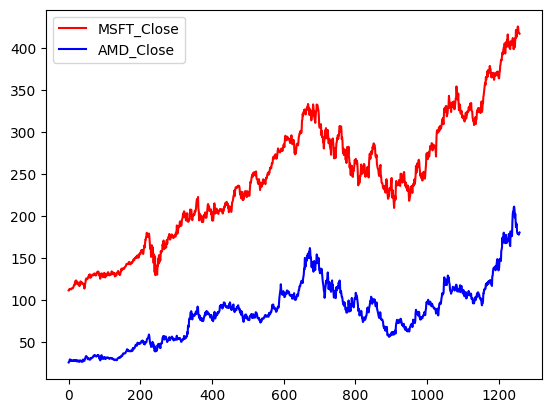

In [16]:
plt.plot(df_raw[first_series],color='r')
plt.plot(df_raw[second_series],color='b')
plt.legend([f'{first_series}',f'{second_series}'])

In [17]:
# Find ratio between co-integrated pairs
coeff = get_cointergrated_coeff(df_raw[first_series],df_raw[second_series])
print(coeff)

-1.939737655744029


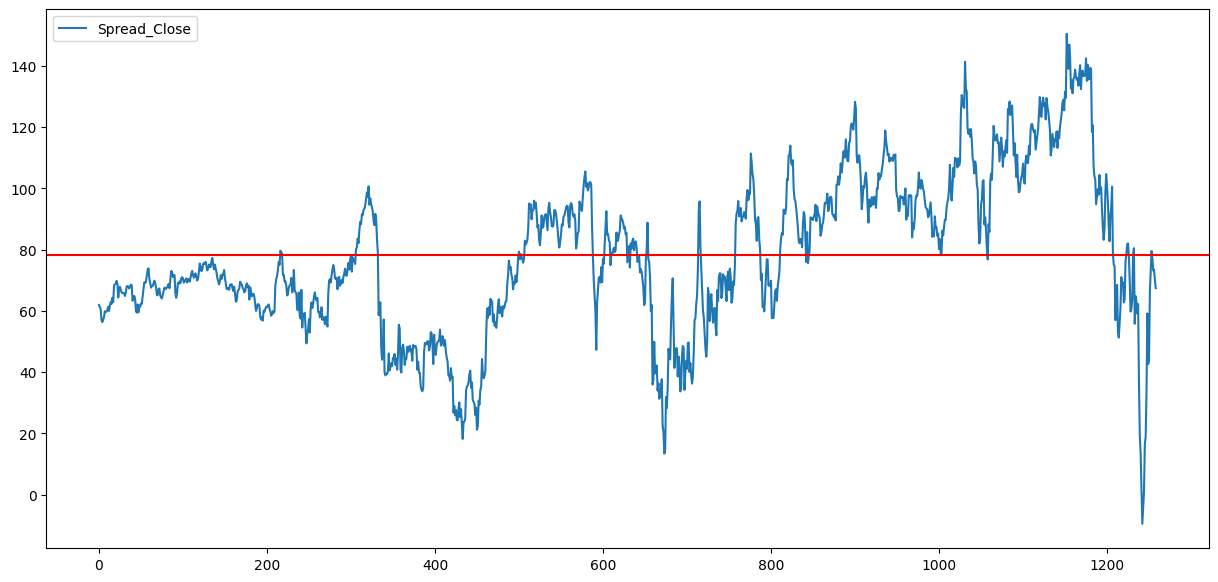

In [18]:
df_raw['Spread_Close'] = df_raw[first_series] + (df_raw[second_series] * coeff)
df_raw['Spread_Close'].plot(figsize=(15,7))
plt.axhline(df_raw['Spread_Close'].mean(),c='red')
plt.legend(['Spread_Close'])

In [19]:
pm = PredictionModeling(df_raw,"Spread_Close",0.60,1)

In [20]:
pm.add_arima_forecast("Spread_Close",order=(1,1,0))

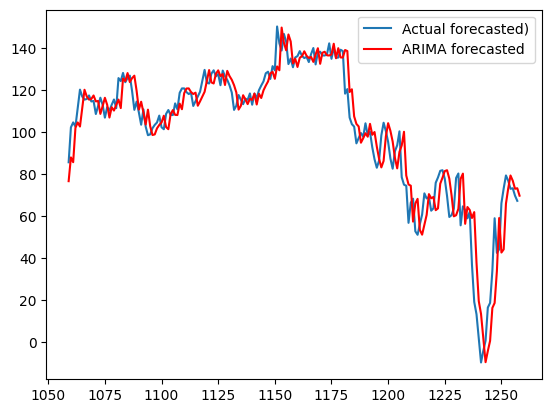

In [21]:
plt.plot(pm.data["Spread_Close_Actual_value_fore_perod_1"][-200:])
plt.plot(pm.data["Spread_Close_ARIMA_forecast_1"][-200:],color='r')
plt.legend(["Actual forecasted)","ARIMA forecasted"])

In [22]:
pm.data

,AMD_Close,AMD_Volume,AMD_Low,AMD_High,MSFT_Close,MSFT_Volume,MSFT_Low,MSFT_High,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,25.520000,53502800,25.250000,25.730000,111.415558,25399800,110.489768,111.774534,61.913452,[61.30432811447408],61.304328,61.304328,NaN,NaN
1,26.360001,63000300,25.830000,26.559999,112.435814,22789100,111.566710,112.520839,61.304328,[60.70843036753863],60.708430,60.708430,NaN,NaN
2,26.750000,53358800,26.090000,26.799999,112.596413,18142300,111.963472,112.870371,60.708430,[57.04205666609732],57.042057,57.042057,NaN,NaN
3,29.020000,197650500,27.879999,29.950001,113.333244,22860700,112.558607,113.767796,57.042057,[56.33003508260541],56.330035,56.330035,NaN,NaN
4,29.090000,82191100,28.610001,29.389999,112.757004,20112800,111.831214,113.578878,56.330035,[57.04410168356151],57.044102,57.044102,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,179.649994,57832100,175.050003,180.759995,425.491516,17636500,422.841763,426.603025,77.017658,[73.16071997760008],73.160720,73.160720,79.506419,[79.50641915099618]
1255,178.630005,71935300,172.000000,182.800003,419.656067,18060500,418.415538,424.171611,73.160720,[73.43410335707546],73.434103,73.434103,77.026242,[77.02624166714865]
1256,177.869995,65322400,176.330002,182.600006,418.455231,16725600,418.157516,422.762344,73.434103,[69.87942946744568],69.879429,69.879429,73.172729,[73.17272931676717]
1257,179.589996,55685600,175.399994,181.229996,418.236908,16705000,415.835261,421.234045,69.879429,[67.42902745711928],67.429027,67.429027,73.433243,[73.43324330167204]


In [23]:
pm.data[:907]

,AMD_Close,AMD_Volume,AMD_Low,AMD_High,MSFT_Close,MSFT_Volume,MSFT_Low,MSFT_High,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,25.520000,53502800,25.250000,25.730000,111.415558,25399800,110.489768,111.774534,61.913452,[61.30432811447408],61.304328,61.304328,NaN,NaN
1,26.360001,63000300,25.830000,26.559999,112.435814,22789100,111.566710,112.520839,61.304328,[60.70843036753863],60.708430,60.708430,NaN,NaN
2,26.750000,53358800,26.090000,26.799999,112.596413,18142300,111.963472,112.870371,60.708430,[57.04205666609732],57.042057,57.042057,NaN,NaN
3,29.020000,197650500,27.879999,29.950001,113.333244,22860700,112.558607,113.767796,57.042057,[56.33003508260541],56.330035,56.330035,NaN,NaN
4,29.090000,82191100,28.610001,29.389999,112.757004,20112800,111.831214,113.578878,56.330035,[57.04410168356151],57.044102,57.044102,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,59.730000,79761600,59.150002,61.770000,226.491379,82543200,225.257671,233.325672,110.630849,[108.34814574238436],108.348146,108.348146,126.215144,[126.21514384196428]
903,58.599998,83871400,58.509998,62.720001,222.016769,40424600,221.067016,228.811905,108.348146,[110.66323657954334],110.663237,110.663237,110.779484,[110.77948350359408]
904,62.009998,78198600,58.919998,62.349998,230.946365,40647700,221.331359,231.661138,110.663237,[110.78382333668152],110.783823,110.783823,108.365021,[108.36502055564733]
905,60.060001,73274100,59.529999,61.860001,227.284470,28357300,226.324916,230.016224,110.783823,[107.68237150526828],107.682372,107.682372,110.645429,[110.64542947948794]


# Data Prepareation of Hyperparameter Tuning for Trading Strategy

In [24]:
total_length =(len(pm.data) - pm.train_end_index)-1
train_size = 0.70
length_param_training = int((len(pm.data) - pm.train_end_index)*0.70)

In [25]:
test_data = pm.data[[first_series,second_series,"Spread_Close","Spread_Close_Actual_value_fore_perod_1","Spread_Close_ARIMA_forecast_1"]][pm.train_end_index:-1]

In [26]:

spread_ARIMA_val = test_data["Spread_Close_ARIMA_forecast_1"][:length_param_training]
S1_val = test_data[first_series][:length_param_training]
S2_val = test_data[second_series][:length_param_training]

spread_ARIMA_test = test_data["Spread_Close_ARIMA_forecast_1"][length_param_training:]

S1_test = test_data[first_series][length_param_training:]
S2_test = test_data[second_series][length_param_training:]

In [27]:
45*4000*6

1080000

# Define set of Hyper parameters

In [28]:
sell_treshold_params = np.linspace(0.4,3,20)
buy_threshold_params = np.linspace(-0.4,-3,20)
clear_threshold_params = np.linspace(0,0.3,10)
window1_param = np.arange(15,100,2)
window2_param = np.arange(1,14,1)
window_param = list(zip(window1_param,window2_param))

param_grid = { 'window1':window1_param,
              'window2':window2_param,
              "sell_threshold":sell_treshold_params,
              "buy_threshold":buy_threshold_params,
              "clear_threshold":clear_threshold_params }
config_dict = {"num_iteration":150}

In [29]:
buy_threshold_params


array([-0.4       , -0.53684211, -0.67368421, -0.81052632, -0.94736842,
       -1.08421053, -1.22105263, -1.35789474, -1.49473684, -1.63157895,
       -1.76842105, -1.90526316, -2.04210526, -2.17894737, -2.31578947,
       -2.45263158, -2.58947368, -2.72631579, -2.86315789, -3.        ])

# Trading Strategy using Trading Strategy using ARIMA

In [46]:

cumilative_return = CumulativeReturn()
byopt =  bayesianOpt(cumilative_return)

In [47]:
params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt.optimize_results["best_params"])
window1 = byopt.optimize_results["best_params"]["window1"]
window2 = byopt.optimize_results["best_params"]["window2"]
sell_threshold = byopt.optimize_results["best_params"]["sell_threshold"]
buy_threshold = byopt.optimize_results["best_params"]["buy_threshold"]
clear_threshold = byopt.optimize_results["best_params"]["clear_threshold"]

Best score: 76299.62822840996: 100%|██████████| 150/150 [01:52<00:00,  1.34it/s]

{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 71, 'window2': 11}


In [32]:
byopt.optimize_results["best_params"] = {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 57, 'window2': 7}

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -466.3453195217081, -466.3453195217081, -466.3453195217081, -466.3453195217081, -466.3453195217081, -466.3453195217081, -466.3453195217081, -466.3453195217081, 21.763271142422127, 505.9064883059762, 992.871616914548, 1480.319644048162, 1978.5697815993365, 2472.5609700612126, 2965.2341817570405, 3448.177585638047, 3937.490178818312, 4436.015343662667, 4942.813773353093, 5445.468606486946, 5948.7920174181645, 6447.28215898435, 6954.395151393649, 7465.110712703567, 7973.002033989217, 8479.42875629023, 8983.66280574701, 9489.28385564666, 9992.479063086394, 10489.922990087549, 10984.453983339348, 11475.646947163386, 11967.306825615908, 12463.489410680231, 12964.303945133794, 13466.70954999594, 13466.70954999594, 13466.70954999594, 13466.70954

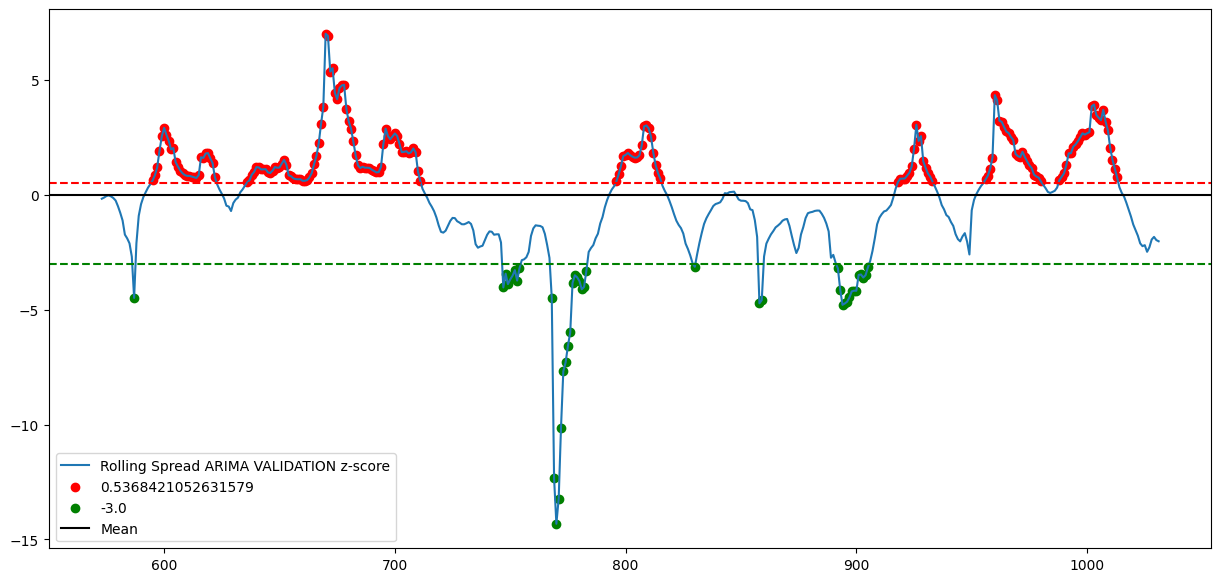

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 534.5034263647148, 1059.1664641305424, 1575.015487014949, 2092.428156981438, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2620.552287448041, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 2082.1767511936814, 1582.1826982439966, 1079.3757979697448, 584.6617310387119, 85.21220782755904, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093, -424.17502175597093,

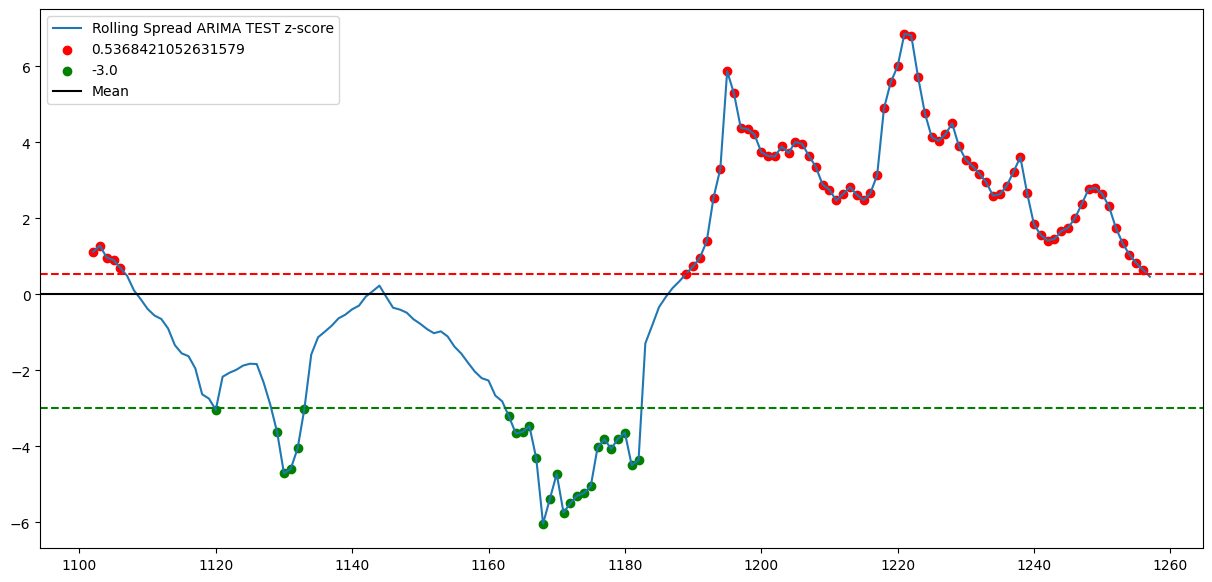

Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 71, 'window2': 11}
Money on validation data 76299.62822840996
Money on test data 36968.994777223976


In [48]:
money_val = byopt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_val)
buy_signal_plots(spread_ARIMA_val,S1_val,S2_val,window1,window2,sell_threshold,buy_threshold,label="ARIMA VALIDATION")

money_test = byopt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_test)
buy_signal_plots(spread_ARIMA_test,S1_test,S2_test,window1,window2,sell_threshold,buy_threshold,label="ARIMA TEST")


print("Optimal Parameters",byopt.optimize_results["best_params"])
print("Money on validation data",money_val[-1])
print("Money on test data",money_test[-1])

In [34]:
exponational_risk = ExponationalUtility(0.006)
byopt_exp =  bayesianOpt(exponational_risk)
params_exp = byopt_exp.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt_exp.optimize_results["best_params"])
window1_exp = byopt_exp.optimize_results["best_params"]["window1"]
window2_exp = byopt_exp.optimize_results["best_params"]["window2"]
sell_threshold_exp = byopt_exp.optimize_results["best_params"]["sell_threshold"]
buy_threshold_exp = byopt_exp.optimize_results["best_params"]["buy_threshold"]
clear_threshold_exp = byopt_exp.optimize_results["best_params"]["clear_threshold"]


Best score: -0.059835787111419896: 100%|██████████| 150/150 [02:37<00:00,  1.05s/it]

{'buy_threshold': -2.4526315789473685, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 21, 'window2': 13}


In [35]:
{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.6736842105263159, 'window1': 23, 'window2': 12}

{'buy_threshold': -3.0,
 'clear_threshold': 0.0,
 'sell_threshold': 0.6736842105263159,
 'window1': 23,
 'window2': 12}

In [49]:
rd_window_1 = 65
rd_window_2 = 10
rd_sell_threshold = 1
rd_buy_threshold = -2
rd_clear_threshold = 0

# Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 65, 'window2': 12}
# Money on validation data 75911.82971778436
# Money on test data 38066.41664118262

In [50]:
money_val_rd = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_val_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_val_exp_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)

In [51]:
# Calculate Exponational Utility

def utility(risk_aversion,money_arr):
    return -1*np.mean(np.exp(-risk_aversion *np.array(money_arr)))

print("Risk Aversion Utility rd",utility(0.009,money_val_rd))
print("Risk Aversion Utility opt",utility(0.009,money_val_opt))
print("Risk Aversion Utility exp",utility(0.009,money_val_exp_opt))


Risk Aversion Utility rd -17104384.766995493
Risk Aversion Utility opt -1.1667237397191297
Risk Aversion Utility exp -0.05838289854050905


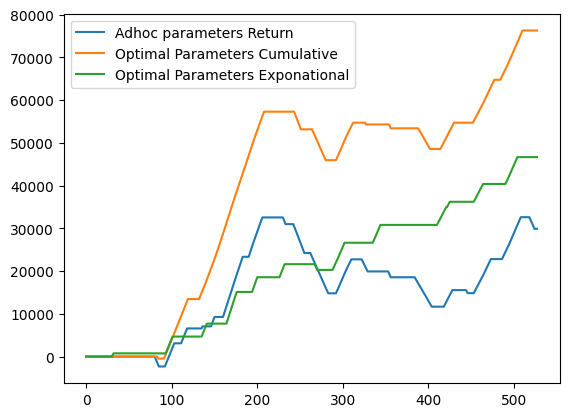

In [52]:
plt.plot(money_val_rd)
plt.plot(money_val_opt)
plt.plot(money_val_exp_opt)
plt.legend(["Adhoc parameters Return","Optimal Parameters Cumulative","Optimal Parameters Exponational"])

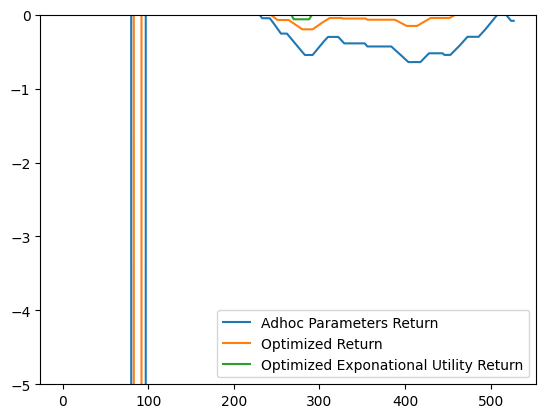

In [53]:
plt.plot(calculate_drawdown(money_val_rd),label="Adhoc Parameters Return")
plt.plot(calculate_drawdown(money_val_opt),label="Optimized Return")
plt.plot(calculate_drawdown(money_val_exp_opt),label="Optimized Exponational Utility Return")
plt.ylim([-5,0])
plt.legend()


In [54]:
val_drawdown = np.min(calculate_drawdown(money_val_rd))
val_opt_drawdown = np.min(calculate_drawdown(money_val_opt))
val_exp_drawdown = np.min(calculate_drawdown(money_val_exp_opt))

print("Val drawdown",val_drawdown)
print("Val optimized drawdown",val_opt_drawdown)
print("Val optimized exponational drawdown",val_exp_drawdown)


Val drawdown -2316.0
Val optimized drawdown -467.0
Val optimized exponational drawdown -0.06233814280429153


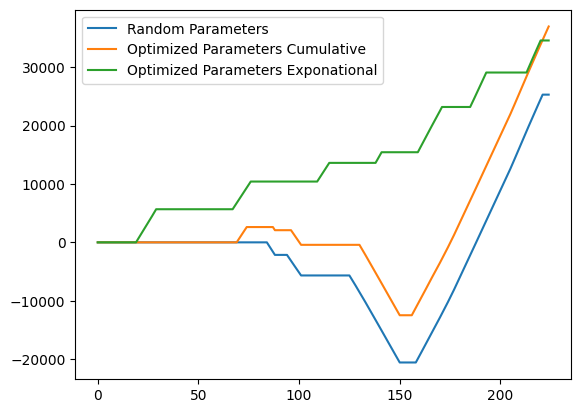

In [55]:
money_test_rd = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_test_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_test_exp_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)
plt.plot(money_test_rd)
plt.plot(money_test_opt)
plt.plot(money_test_exp_opt)
plt.legend(["Random Parameters","Optimized Parameters Cumulative","Optimized Parameters Exponational"])

In [56]:
print("Money gain using random parameters",money_test_rd[-1])
print("Money gain using optimized parameters",money_test_opt[-1])
print("Money gain using optimized parameters exponational",money_test_exp_opt[-1])

print("Performance gain over benchmark Cumilative  ",(money_test_opt[-1]- money_test_rd[-1])/money_test_rd[-1])

print("Performance gain over benchmark exponational",(money_test_exp_opt[-1]- money_test_rd[-1])/money_test_rd[-1])


Money gain using random parameters 25296.31848793107
Money gain using optimized parameters 36968.994777223976
Money gain using optimized parameters exponational 34572.03669240267
Performance gain over benchmark Cumilative   0.46143775011616683
Performance gain over benchmark exponational 0.36668253559888825


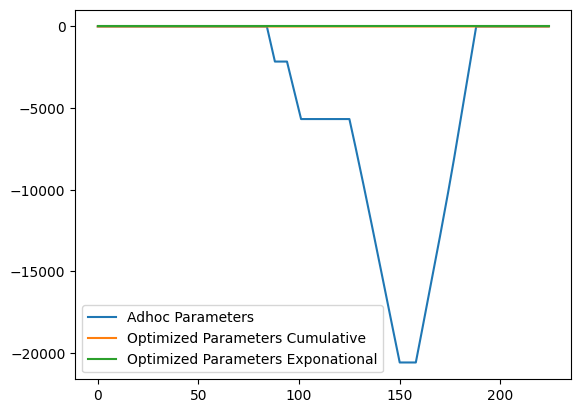

In [57]:
plt.plot(calculate_drawdown(money_test_rd),label="Adhoc Parameters")
plt.plot(calculate_drawdown(money_test_opt),label="Optimized Parameters Cumulative")
plt.plot(calculate_drawdown(money_test_exp_opt),label="Optimized Parameters Exponational")
# plt.ylim(-1,0)
plt.legend()

In [58]:
val_test_rd = calculate_drawdown(money_test_rd)
val_test_opt = calculate_drawdown(money_test_opt)
val_test_exp_op = calculate_drawdown(money_test_exp_opt)

print("Test drawdown",np.min(val_test_rd))
print("Test optimized drawdown",np.min(val_test_opt))
print("Test optimized drawdown",np.min(val_test_exp_op))

#Reduction in drawdown
print("Reduction in drawdown Cumilative  ",(np.min(val_test_rd)-np.min(val_test_opt))/np.min(val_test_rd))
print("Reduction in drawdown Exponational  ",(np.min(val_test_rd)-np.min(val_test_exp_op))/np.min(val_test_rd))





Test drawdown -20571.0
Test optimized drawdown -5.763740458015267
Test optimized drawdown 0.0
Reduction in drawdown Cumilative   0.9997198123349368
Reduction in drawdown Exponational   1.0


In [59]:
# Calculate sharpe from wealth
def sharpe_ratio(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    return (np.mean(daily_returns) / np.std(daily_returns))*np.sqrt(252)

# Calculate sharpe ratio on test data
sharpe_rd = sharpe_ratio(money_test_rd)
sharpe_opt = sharpe_ratio(money_test_opt)
sharpe_exp = sharpe_ratio(money_test_exp_opt)

print("Sharpe Ratio Random Parameters",sharpe_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_exp)

Sharpe Ratio Random Parameters -0.9432139863363254
Sharpe Ratio Optimized Parameters 1.0512853301874474
Sharpe Ratio Optimized Parameters Exponational 1.071991040375507


In [65]:
len(money_val_rd)

528

In [ ]:
# Calculate average drawdowns
def average_drawdown(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    drawdowns = (np.maximum.accumulate(daily_returns) - daily_returns)
    return np.mean(drawdowns)

In [67]:
# calculate returns from portfolio wealth using numpy 
np.diff(money_val_rd)/money_val_rd[:-1]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [64]:
# Calculate sharpe on validation data
sharpe_val_rd = sharpe_ratio(money_val_rd)
sharpe_val_opt = sharpe_ratio(money_val_opt)
sharpe_val_exp = sharpe_ratio(money_val_exp_opt)
print("Sharpe Ratio Random Parameters",sharpe_val_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_val_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_val_exp)

Sharpe Ratio Random Parameters -0.6811437247952171
Sharpe Ratio Optimized Parameters -0.6516969676936798
Sharpe Ratio Optimized Parameters Exponational 0.702276821866319


In [63]:
returns = pd.Series(money_test_exp_opt).pct_change()[1:]
portfolio_returns = pd.Series(money_test_exp_opt).sum(axis=1)
# cumulative_returns = (1 + portfolio_returns).cumprod() * 
cumilative_returns = money_test_exp_opt

# roi = (cumulative_returns[-1] / self.portfolio_value - 1) * 100
sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
drawdown = (cumilative_returns.cummax() - cumilative_returns) / cumilative_returns.cummax()
max_drawdown = drawdown.max() * 100

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

ValueError: No axis named 1 for object type Series

In [49]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
result = adfuller(pm.data['Spread_Close'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.663120
p-value: 0.004663


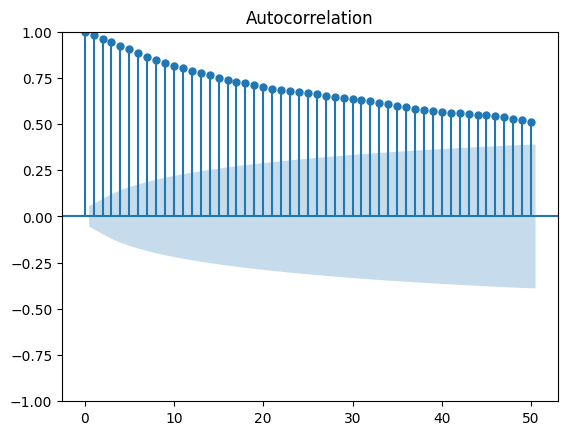

In [ ]:
plot_acf(pm.data['Spread_Close'],lags=50)
plt.show()

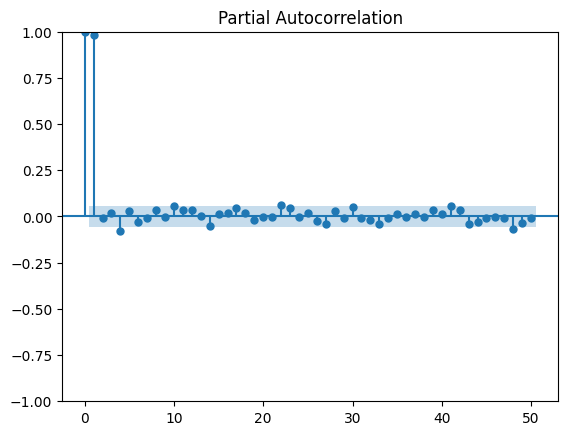

In [135]:
plot_pacf(pm.data['Spread_Close'],lags=50)
plt.show()

In [136]:
result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -19.470556
p-value: 0.000000


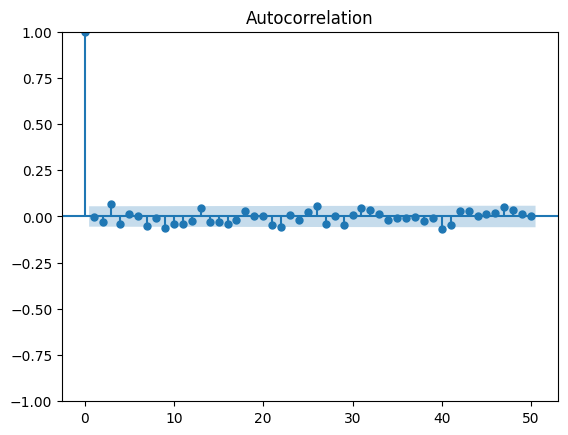

In [137]:
plot_acf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

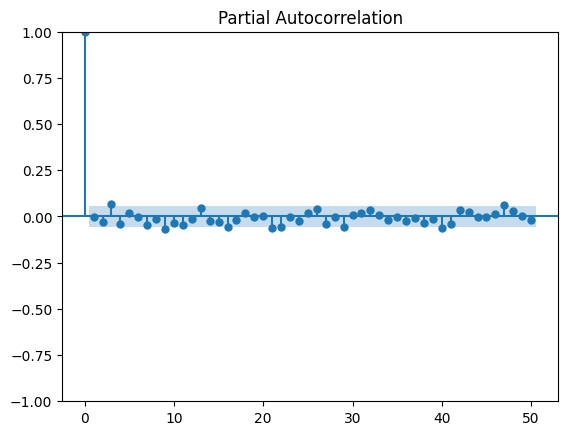

In [138]:
plot_pacf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [139]:

result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -19.470556
p-value: 0.000000
